In [1]:
try:
    print_spark_info()
except:
    %run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/g.luvizottocesar@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [23]:
clean_spark()

CLEANING SPARK INSTANCE...


In [3]:
import os
from datetime import datetime
import time
import logging
import re

import ipaddress
import publicsuffixlist as psl

# installed pkg imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pyspark related imports
import pyspark.sql.types as pst
from pyspark.sql import functions as psf
from pyspark.sql.window import Window

# local imports
from census_helper import download_date

In [4]:
# Create logger
logger = logging.getLogger("anycast_services")
logger.setLevel(logging.INFO)

# Prevent duplicate logs if logger already has handlers
if not logger.handlers:
    # Create file handler
    file_handler = logging.FileHandler("logs.log", encoding='utf-8')
    file_handler.setLevel(logging.INFO)
    
    # Create formatter
    formatter = logging.Formatter(
        fmt='%(asctime)s %(levelname)-8s %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    
    # Add formatter to handler
    file_handler.setFormatter(formatter)
    
    # Add handler to logger
    logger.addHandler(file_handler)
else:
    print("logger already exist!")

# Optionally, prevent propagation to root logger to avoid duplicates
logger.propagate = False

In [23]:
## Create PublicSuffixList
# NOTE: Update PSL.dat if older than a day!
if time.time() - os.path.getctime("/opt/conda/lib/python3.10/site-packages/publicsuffixlist/public_suffix_list.dat") > (24*3600):
    print("Updating PSL file.")
    !python -m publicsuffixlist.update
else:
    !python -m publicsuffixlist.test 

...........................................
----------------------------------------------------------------------
Ran 43 tests in 1.935s

OK


# One-off measurement

## ZGrab

ZGrab input format:  

ip,domain,tag,port  

header=False, index=False

In [12]:
snapshot = datetime(2026, 3, 3)
vp = "de-mun"
ds_tcp = "tcp-anycast"

### Exporting openintel domain names under anycast prefixes

In [5]:
_anycast_pdf = download_date(snapshot, "v4")
anycast_pdf = _anycast_pdf[_anycast_pdf['GCD_ICMPv4'] > 1]["prefix"].copy() # filter on GCD-confirmed (high accuracy)

anycast_prefixes = spark.createDataFrame(anycast_pdf, schema=pst.StringType()).withColumnRenamed("value", "prefix")

In [6]:
# Base prefix of fDNS warehouse data
FDNS_WAREHOUSE_BASE = "s3a://openintel/category=fdns/type=warehouse"
# Prefix format() template for (source, date)-partition fDNS warehouse data
FDNS_SOURCE_DT_PARTITION_FMT_TEMPLATE = os.path.join(FDNS_WAREHOUSE_BASE, "source={source}", "year={year}", "month={month:02d}", "day={day:02d}")


sources = [
    "tranco",
    "com", "net", "org", "info", "mobi", "gov", "name", "asia", "czds",
    "nl", "se", "nu", "ca", "fi", "at", "dk", "us", "gt", "na", "ee", "co", "ch", "li", "sk", "fr", "cl",
    "umbrella", "radar", "majestic", "crux",
    "biz",
    "closedcc",
    "imp",
    "opencc",
    "root",
    "su",
]

psl_obj = psl.PublicSuffixList()
tld_regex_dict = {}
for tld in psl.PublicSuffixList()._publicsuffix:
    # https://github.com/publicsuffix/list/wiki/Format
    tld_escaped = tld.replace("*.", "[a-zA-Z]*.?").replace("!", "")  # ! is a prefference over the generic rule
    _domain_pattern = fr'([^.]+)[.]({tld_escaped}).?$'
    tld_clean = tld.replace("*.", "").replace("!", "")
    tld_regex_dict[tld_clean] = re.compile(_domain_pattern, re.IGNORECASE)


def extract_apex_domain_logic(x: str, psl_obj, tld_regex_dict):
    # x: query_name
    if x is None:
        return None

    # invalid case:query:_dmarc.siter.io., txt_text contains ma""ilinblue.com!10m
    #                                                           x
    # invalid case:query:_dmarc.fnspfdr.sk, txt_text contains rua=mailto:dmarc@hostcreators.sk ruf=mailto:dmarc@hostcreators.sk; resulting in a rua_domain:hostcreators.sk hostcreators.sk
    #                                                                                         x
    if '"' in x or ' ' in x:
        return None

    tld = psl_obj.publicsuffix(x)  # get the com.br from a.example.com.br
    if tld is None:
        return None  # invalid suffix

    # to avoid cases such as v.ua
    tld_escaped = tld.replace("*.", "")
    if tld_escaped == x.rstrip("."):
        return tld_escaped

    x_escaped = x
    # rfc7489#section-6.2
    #   For example, the URI "mailto:reports@example.com!50m" would request
    #   that a report be sent via email to "reports@example.com" so long as
    #   the report payload does not exceed 50 megabytes.
    if "!" in tld_escaped:
        tld_escaped = ''.join(tld_escaped.split("!")[0])
        x_escaped = ''.join(x.split("!")[0])

    try:
        prog = tld_regex_dict[tld_escaped]
    except KeyError:
        if "." in tld:
            catch_all_tld = tld.split(".")[-1]
            prog = tld_regex_dict[catch_all_tld]
        else:
            return None

    m = prog.search(x_escaped)
    if m:
        return f"{m.group(1).strip()}.{m.group(2).strip()}"
    return None


broadcast_psl_obj = spark.sparkContext.broadcast(psl_obj)
broadcast_tld_regex = spark.sparkContext.broadcast(tld_regex_dict)

@psf.pandas_udf(pst.StringType())
def extract_apex_domain(query_name: pd.Series) -> pd.Series:
    _psl_obj = broadcast_psl_obj.value
    _tld_regex_dict = broadcast_tld_regex.value
    return query_name.apply(lambda x: extract_apex_domain_logic(x, _psl_obj, _tld_regex_dict))


def extract_tld_logic(x, psl_obj):
    """
    Extract country code TLD from a domain name.
    
    Args:
        x: Domain name string
        psl_obj: PublicSuffixList object for extracting TLDs

    Returns:
        Extracted country code TLD or government TLD
    """
    if x is None:
        return None
    tld = psl_obj.publicsuffix(x)
    if False:
        if tld is None:
            return None
        cctld = tld.split(".")[-1]  # br from example.com.br
    
        # when using this function to extract rua/ruf etld...
        # rfc7489#section-6.2
        #   For example, the URI "mailto:reports@example.com!50m" would request
        #   that a report be sent via email to "reports@example.com" so long as
        #   the report payload does not exceed 50 megabytes.
        if "!" in cctld:
            return cctld.split("!")[0]
        return cctld
    return tld


@psf.pandas_udf(pst.StringType())
def extract_tld(query_name: pd.Series) -> pd.Series:
    # extract the .br from example.com.br because we don't need a second level tld to identify a domain from a country
    _psl_obj = broadcast_psl_obj.value
    return query_name.apply(lambda x: extract_tld_logic(x, _psl_obj))

In [27]:
# CHECK BEFORE RUN! probably this data is already stored...
for source in sources:
    t1 = time.time()
    try:
        df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}")
    except:
        logger.info(f"{source} not available")
        continue

    df.select("query_type", "ip4_address", "response_name").filter(
        (psf.col("query_type") == "A")
        & (psf.col("ip4_address").isNotNull())
    ).withColumn(
        "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
    ).join(
        psf.broadcast(anycast_prefixes), on="prefix", how="inner"
    ).withColumn(
        "hostname", extract_apex_domain(psf.col("response_name"))
    ).select(psf.col("ip4_address").alias("ip"), "hostname"
    ).distinct().filter(psf.col("hostname").isNotNull()).write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/name_analysis/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/")

    t2 = time.time()
    print(source, "took", round(t2-t1, 1), "seconds to process")
    logger.info(f"{source} took {round(t2-t1, 1)}s to process")

tranco took 30.6 seconds to process
com took 347.7 seconds to process
net took 40.9 seconds to process
org took 39.6 seconds to process
info took 33.2 seconds to process
mobi took 13.0 seconds to process
gov took 2.5 seconds to process
name took 4.3 seconds to process
asia took 12.4 seconds to process
czds took 97.3 seconds to process
nl took 25.6 seconds to process
se took 12.3 seconds to process
nu took 6.5 seconds to process
ca took 37.9 seconds to process
fi took 14.4 seconds to process
at took 18.3 seconds to process
dk took 11.6 seconds to process
us took 34.8 seconds to process
gt took 2.7 seconds to process
na took 2.2 seconds to process
ee took 7.4 seconds to process
co took 34.0 seconds to process
ch took 17.4 seconds to process
li took 3.8 seconds to process
sk took 11.0 seconds to process
fr took 24.7 seconds to process
cl took 18.4 seconds to process
umbrella took 26.7 seconds to process
radar took 23.1 seconds to process
majestic took 24.0 seconds to process
crux took 43.

### TLS scans

In [13]:
lzr_ts = snapshot
LZR_BASE_PATH = "s3a://catrin/measurements/tool=lzr/dataset={ds}/format=parquet/vp={vp}"
LZR_PATH = "port=*/year={year}/month={month:02d}/day={day:02d}"

lzr_path_f = os.path.join(LZR_BASE_PATH.format(ds=ds_tcp, vp=vp), LZR_PATH.format(year=lzr_ts.year, month=lzr_ts.month, day=lzr_ts.day))
lzr_df = spark.read.option("basePath", LZR_BASE_PATH.format(ds=ds_tcp, vp=vp)).parquet(lzr_path_f)
lzr_df.printSchema()

root
 |-- ACK: boolean (nullable = true)
 |-- ACKed: boolean (nullable = true)
 |-- Counter: long (nullable = true)
 |-- FIN: boolean (nullable = true)
 |-- HandshakeNum: long (nullable = true)
 |-- PUSH: boolean (nullable = true)
 |-- RST: boolean (nullable = true)
 |-- SYN: boolean (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- acknum: long (nullable = true)
 |-- daddr: string (nullable = true)
 |-- data: string (nullable = true)
 |-- dport: long (nullable = true)
 |-- expectedRToLZR: string (nullable = true)
 |-- fingerprint: string (nullable = true)
 |-- saddr: string (nullable = true)
 |-- seqnum: long (nullable = true)
 |-- sport: long (nullable = true)
 |-- ttl: long (nullable = true)
 |-- window: long (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- port: integer (nullable = true)



In [7]:
zgrab_tls_port_module_map = {
    5671: "amqps",
    443: "https",
    465: "smtps",
    990: "ftps",
    993: "imaps",
    995: "pop3s",
    #587: "smtpss",  <- scan on 20 of Feb  <- no good
    587: "smtp",  # <- another scan on Feb 24  <- no good
    25: "smtp",  # <- another scan on Feb 24  <- no good
    143: "imap",  # <- another scan on Feb 24  <- no good
}


mapping_expr = psf.create_map(
    *[psf.lit(x) for kv in zgrab_tls_port_module_map.items() for x in kv]
)

#### Without domain names

In [14]:
# WITHOUT HOSTNAME

lzr_df.filter(
    psf.col("fingerprint").isin(["tls", "ssl"])
).withColumn(
    "hostname", psf.lit(None).cast("string")
).withColumn(
    "tag", psf.coalesce(mapping_expr[psf.col("port")], psf.lit("https"))
).select("saddr", "hostname", "tag", "port").distinct(
).coalesce(1).write.option("nullValue", "").option("emptyValue", "").csv(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/zgrab/input/tls_scans/vp={vp}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}", header=False, emptyValue='')

#### With domain names

In [8]:
tls_ips_df = lzr_df.filter(
    psf.col("fingerprint").isin(["tls", "ssl"])
).select(psf.col("saddr").alias("ip")).distinct()

In [8]:
tls_ips_df.write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/lzr/tls_ips/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}")

In [9]:
tls_ips_df = spark.read.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/lzr/tls_ips/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}")

In [9]:
tls_ips_df = tls_ips_df.repartition(24, "ip")
tls_ips_df.count()

# nl-ens 707692
# au-syd 1111271

1111271

##### Extracting domain names for TLS IPs

In [10]:
oi_df = spark.read.option("basePath", "s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/name_analysis/"
).parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/name_analysis/"
).filter(
    (psf.col("year") == psf.lit(snapshot.year))
    & (psf.col("month") == psf.lit(snapshot.month))
    & (psf.col("day") == psf.lit(snapshot.day))
).filter(
    ~(psf.col("source").isin(["all", "ip6-chli"]))
).filter(
    psf.col("hostname").isNotNull()
).dropDuplicates(subset=["ip"])

oi_df = oi_df.repartition(24, "ip")

tls_ips_domain_df = tls_ips_df.join(
    oi_df,
    on=["ip"],
    how="left",
)

In [11]:
oi_df.show()

+--------------+--------------------+--------+----+-----+---+
|            ip|            hostname|  source|year|month|day|
+--------------+--------------------+--------+----+-----+---+
|104.109.11.129|      dreamforce.com|     com|2026|    2| 18|
|   104.16.12.9|edu.cdn.cloudflar...|   radar|2026|    2| 18|
| 104.16.122.43|        glassdoor.ch|   radar|2026|    2| 18|
|104.16.154.185|    carmodshop.co.uk|    crux|2026|    2| 18|
|104.16.169.172|   xingfayule666.com|     com|2026|    2| 18|
| 104.16.193.46|       skoleintra.dk|   radar|2026|    2| 18|
|104.16.207.244|     cdnondemand.org|     org|2026|    2| 18|
| 104.16.216.81|com.cdn.cloudflar...|   radar|2026|    2| 18|
|104.16.219.250|     merlenorman.com|   radar|2026|    2| 18|
| 104.16.220.85|computingatschool...|   radar|2026|    2| 18|
|104.16.240.154|cloudflarepackage...|     com|2026|    2| 18|
|  104.16.37.11|        utbank.co.uk|majestic|2026|    2| 18|
|  104.16.59.99|       bestsecret.fr|  opencc|2026|    2| 18|
| 104.16

In [12]:
tls_ips_df.show()

+---------------+
|             ip|
+---------------+
|  23.145.208.22|
| 13.249.171.127|
|  35.227.204.73|
|103.180.114.203|
|   34.98.66.182|
|    34.8.69.203|
|  35.201.116.45|
|  35.227.221.43|
|  34.117.63.175|
|  35.201.61.251|
|   52.223.14.75|
| 35.186.217.213|
|  34.160.61.121|
|  34.149.141.15|
|    34.117.18.2|
|166.117.118.247|
| 166.117.67.121|
| 13.248.128.189|
|   34.111.128.1|
|  99.83.208.236|
+---------------+
only showing top 20 rows



In [13]:
try:
    tls_ips_domain_df.unpersist()
except:
    pass

tls_ips_domain_df.persist()

DataFrame[ip: string, hostname: string, source: string, year: int, month: int, day: int]

In [14]:
tls_ips_domain_df.show()

+---------------+-------------+------+----+-----+----+
|             ip|     hostname|source|year|month| day|
+---------------+-------------+------+----+-----+----+
|  1.228.251.245|         NULL|  NULL|NULL| NULL|NULL|
|   1.253.164.91|         NULL|  NULL|NULL| NULL|NULL|
|102.132.188.145|         NULL|  NULL|NULL| NULL|NULL|
|102.177.176.224|         NULL|  NULL|NULL| NULL|NULL|
|102.177.176.244|         NULL|  NULL|NULL| NULL|NULL|
| 103.11.212.196|         NULL|  NULL|NULL| NULL|NULL|
|  103.11.214.74|365365104.com|   com|2026|    2|  18|
|    103.116.4.1|         NULL|  NULL|NULL| NULL|NULL|
|  103.135.111.1|         NULL|  NULL|NULL| NULL|NULL|
|103.160.204.117|         NULL|  NULL|NULL| NULL|NULL|
|103.182.250.249|         NULL|  NULL|NULL| NULL|NULL|
|103.227.200.137|         NULL|  NULL|NULL| NULL|NULL|
|103.230.172.158|         NULL|  NULL|NULL| NULL|NULL|
|  103.250.6.105|         NULL|  NULL|NULL| NULL|NULL|
|  103.250.6.141|         NULL|  NULL|NULL| NULL|NULL|
|  103.250

In [15]:
# nr of IPs with domain name:
tls_ips_domain_df.filter(
    psf.col("hostname").isNotNull()
).count()

# 4th feb 67939
# 18th feb
# nl ens 88707
# au syd 115551

115551

In [16]:
# nr of IPs without domain name:
tls_ips_domain_df.filter(
    psf.col("hostname").isNull()
).count()

# 4th feb 353269
# 18th feb
# nl ens 618985
# au syd 995720

995720

In [19]:
115551+995720 == tls_ips_df.count()

True

##### Build list of ip, domain, tag, port

In [26]:
# WITH HOSTNAME

lzr_df.filter(
    psf.col("fingerprint").isin(["tls", "ssl"])
).select(psf.col("saddr").alias("ip"), "port").distinct().join(
    tls_ips_domain_df,
    on=["ip"],
    how="inner",
).withColumn(
    "tag", psf.coalesce(mapping_expr[psf.col("port")], psf.lit("https"))
).select("ip", "hostname", "tag", "port").distinct(
).coalesce(1).write.csv(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/zgrab/input/tls_scans_sni/vp={vp}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}", header=False)

In [45]:
lzr_df.filter(
    psf.col("fingerprint").isin(["tls", "ssl"])
).withColumn(
    "domain", psf.lit("")
).withColumn(
    "tag", psf.coalesce(mapping_expr[psf.col("port")], psf.lit("https"))
).select("saddr", "domain", "tag", "port", "year", "month", "day"
).count()

476349

In [13]:
tls_ports = lzr_df.filter(
    psf.col("fingerprint").isin(["tls", "ssl"])
).select("port").distinct().toPandas()["port"].to_list()

In [32]:
def expand_range(value):
    if "-" in value:
        start, end = map(int, value.split("-"))
        return list(range(start, end + 1))
    else:
        return [int(value)]


service_names_pdf = pd.read_csv("service-names-port-numbers.csv")

filtered_service_names_pdf = service_names_pdf[
    (~service_names_pdf["Port Number"].isnull())
    & (~service_names_pdf["Service Name"].isnull())
    & (service_names_pdf["Transport Protocol"] == "tcp")
].copy()

filtered_service_names_pdf["Port Number"] = filtered_service_names_pdf["Port Number"].apply(expand_range)
filtered_service_names_pdf = filtered_service_names_pdf.explode("Port Number").reset_index(drop=True)
filtered_service_names_pdf["Port Number"] = filtered_service_names_pdf["Port Number"].astype(int)

display(filtered_service_names_pdf)

,Service Name,Port Number,Transport Protocol,Description,Assignee,Contact,Registration Date,Modification Date,Reference,Service Code,Unauthorized Use Reported,Assignment Notes
0,tcpmux,1,tcp,TCP Port Service Multiplexer,[Mark_Lottor],[Mark_Lottor],NaN,NaN,NaN,NaN,NaN,NaN
1,rje,5,tcp,Remote Job Entry,[Jon_Postel],[Jon_Postel],NaN,NaN,NaN,NaN,NaN,NaN
2,echo,7,tcp,Echo,[Jon_Postel],[Jon_Postel],NaN,NaN,NaN,NaN,NaN,NaN
3,discard,9,tcp,Discard,[Jon_Postel],[Jon_Postel],NaN,NaN,NaN,NaN,NaN,NaN
4,systat,11,tcp,Active Users,[Jon_Postel],[Jon_Postel],NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
6066,iqobject,48619,tcp,iqobject,[Bjorn_de_Bonnenfant],[Bjorn_de_Bonnenfant],2003-11,NaN,NaN,NaN,NaN,NaN
6067,robotraconteur,48653,tcp,Robot Raconteur transport,[Wason_Technology_LLC],[John_Wason],2014-01-27,NaN,NaN,NaN,NaN,NaN
6068,matahari,49000,tcp,Matahari Broker,[Matahari_Project],[Zane_Bitter],2011-08-31,NaN,NaN,NaN,NaN,NaN
6069,nusrp,49001,tcp,Nuance Unity Service Request Protocol,[Nuance_Communications_Inc3],[Andrew_Andrews],2017-04-20,NaN,NaN,NaN,NaN,NaN


In [38]:
filtered_service_names_pdf[filtered_service_names_pdf["Port Number"].isin(tls_ports)]
    

,Service Name,Port Number,Transport Protocol,Description,Assignee,Contact,Registration Date,Modification Date,Reference,Service Code,Unauthorized Use Reported,Assignment Notes
2,echo,7,tcp,Echo,[Jon_Postel],[Jon_Postel],NaN,NaN,NaN,NaN,NaN,NaN
3,discard,9,tcp,Discard,[Jon_Postel],[Jon_Postel],NaN,NaN,NaN,NaN,NaN,NaN
5,daytime,13,tcp,Daytime,[Jon_Postel],[Jon_Postel],NaN,NaN,[RFC867],NaN,NaN,NaN
9,ftp-data,20,tcp,File Transfer [Default Data],[Jon_Postel],[Jon_Postel],NaN,NaN,NaN,NaN,NaN,NaN
11,ssh,22,tcp,The Secure Shell (SSH) Protocol,NaN,NaN,NaN,NaN,[RFC4251],NaN,NaN,Defined TXT keys: u=<username> p=<password>
...,...,...,...,...,...,...,...,...,...,...,...,...
5510,ndmp,10000,tcp,Network Data Management Protocol,[Brian_Ehrmantraut],[Brian_Ehrmantraut],NaN,NaN,NaN,NaN,NaN,NaN
5590,memcache,11211,tcp,Memory cache service,[Trond_Norbye],[Trond_Norbye],2009-02-09,NaN,NaN,NaN,NaN,NaN
5764,dnp,20000,tcp,DNP,[Michael_Thesing],[Michael_Thesing],NaN,NaN,NaN,NaN,NaN,NaN
5891,mongodb,27017,tcp,Mongo database system,[MongoDB_Inc.],[Akshay_Kumar],2019-02-21,NaN,NaN,NaN,NaN,NaN


In [49]:
filtered_service_names_pdf[
    (filtered_service_names_pdf["Port Number"].isin(tls_ports))
    & (
        (filtered_service_names_pdf["Description"].str.contains("tls", case=False, na=False))
        | (filtered_service_names_pdf["Description"].str.contains("ssl", case=False, na=False))
    )
]

,Service Name,Port Number,Transport Protocol,Description,Assignee,Contact,Registration Date,Modification Date,Reference,Service Code,Unauthorized Use Reported,Assignment Notes
355,https,443,tcp,http protocol over TLS/SSL,[IESG],[IETF_Chair],NaN,2021-10-01,[RFC9110],NaN,NaN,NaN
378,submissions,465,tcp,Message Submission over TLS protocol,[IESG],[IETF_Chair],2017-12-12,NaN,[RFC8314],NaN,NaN,NaN
692,ftps,990,tcp,"ftp protocol, control, over TLS/SSL",[Christopher_Allen],[Christopher_Allen],NaN,NaN,NaN,NaN,NaN,NaN
694,telnets,992,tcp,telnet protocol over TLS/SSL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
695,imaps,993,tcp,IMAP over TLS protocol,[IESG],[IETF_Chair],NaN,2021-02-22,[RFC3501][RFC8314][RFC9051],NaN,NaN,NaN
696,pop3s,995,tcp,POP3 over TLS protocol,[IESG],[IETF_Chair],NaN,2017-12-12,[RFC8314],NaN,NaN,NaN
4509,amqps,5671,tcp,amqp protocol over TLS/SSL,[Ted_Ross_2],[Ted_Ross_2],2008-03-26,NaN,NaN,NaN,NaN,NaN


In [51]:
filtered_service_names_pdf[filtered_service_names_pdf["Port Number"] == 587]

,Service Name,Port Number,Transport Protocol,Description,Assignee,Contact,Registration Date,Modification Date,Reference,Service Code,Unauthorized Use Reported,Assignment Notes
499,submission,587,tcp,Message Submission,NaN,NaN,NaN,2011-11-17,[RFC6409],NaN,NaN,NaN


### SSH scans

In [21]:
# ssh on nl-ens, au-syd, de-mun

vp = "de-mun"
snapshot = datetime(2026, 3, 3)
ds_tcp = "tcp-anycast"

lzr_path_f = os.path.join(LZR_BASE_PATH.format(ds=ds_tcp, vp=vp), LZR_PATH.format(year=lzr_ts.year, month=lzr_ts.month, day=lzr_ts.day))
lzr_df = spark.read.option("basePath", LZR_BASE_PATH.format(ds=ds_tcp, vp=vp)).parquet(lzr_path_f)

In [22]:
lzr_df.filter(
    psf.col("fingerprint") == "ssh"
).withColumn(
    "hostname", psf.lit(None).cast("string")
).withColumn(
    "tag", psf.lit("ssh")
).select("saddr", "hostname", "tag", "port").distinct(
).coalesce(1).write.option("nullValue", "").option("emptyValue", "").csv(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/zgrab/input/ssh_scans/vp={vp}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}", header=False, emptyValue='')

# OLD input generation -- replaced by on-the-fly input collection

## QUIC input

In [25]:
ts = datetime(2025, 6, 3)  # this is the latest we have now...
# the dataset of this date, in parquet format, has:
# Total Size: 2.2 TiB
# Total Objects: 1025

# virtual hosts data set uses names in the scan.
# more info: https://docs.censys.com/docs/ls-intro-virtual-hosts

# how they obtain the names (from their latest paper): https://doi.org/10.1145/3718958.3754344
# "Censys performs HTTP(S) scans against known names, which it collects from public CT logs, HTTP redirects, and third-party passive DNS subscriptions.
# We initially began to perform name-based scanning as an extension to IP-based scanning by creating a new asset type—Virtual Host"
CENSYS_BASE_PATH_FMT = "s3a://censys/dataset=universal-internet-dataset-v2-ipv4-virtual-hosts/format=parquet/"
CENSYS_PATH_FMT = os.path.join(CENSYS_BASE_PATH_FMT, "year={year}/month={month:02d}/day={day:02d}")

In [26]:
censys_path = CENSYS_PATH_FMT.format(year=ts.year, month=ts.month, day=ts.day)
censys_vh_df = spark.read.parquet(censys_path)

In [34]:
censys_vh_df.select("host_identifier.ipv4", "host_identifier.name", "dns.names").show(truncate=False)

+---------------+----------------------------------------------------+-----+
|ipv4           |name                                                |names|
+---------------+----------------------------------------------------+-----+
|147.81.11.183  |dhcp-147-81-11-183.hawaiiantel.net                  |NULL |
|103.4.75.81    |test5.demo.idt.pf                                   |NULL |
|184.28.179.245 |a184-28-179-245.deploy.static.akamaitechnologies.com|NULL |
|206.87.224.50  |www.sandbox.neuroscience.ubc.ca                     |NULL |
|209.54.113.150 |www.getflushed.ca                                   |NULL |
|209.54.113.159 |www.lucidcapital.slant.is                           |NULL |
|23.180.104.243 |mail.dispatchbvsltd.ca                              |NULL |
|64.34.50.39    |dlccontinentalmortgage.ca                           |NULL |
|67.231.16.157  |cpcalendars.brightoncollege.ca                      |NULL |
|67.231.16.180  |webmail.akirawebhosting.com                         |NULL |

In [35]:
censys_vh_df.filter(
    psf.col("dns.names").isNotNull()
).select("host_identifier.ipv4", "host_identifier.name", "dns.names").show(truncate=False)

+----+----+-----+
|ipv4|name|names|
+----+----+-----+
+----+----+-----+



In [33]:
# checking if there are more names attached to the same IP address
censys_vh_df.groupBy("host_identifier.ipv4", "host_identifier.name").count().sort("count", ascending=False).show(truncate=False)

+--------------+-------------------------------------------------------------------------+-----+
|ipv4          |name                                                                     |count|
+--------------+-------------------------------------------------------------------------+-----+
|172.65.90.27  |18c32dd7b2d963c07a6cc38586637ee9.fedramp.r2.cloudflarestorage.com        |1    |
|172.64.150.67 |anelsonhaframeworksebstocraftgasme.tebex.io                              |1    |
|172.66.47.110 |legend-ek5.pages.dev                                                     |1    |
|172.66.0.70   |jukeboxomnibus.one                                                       |1    |
|34.117.166.186|sampler-92-wave-1-0-12525034100419702288.http-01.preprod.haplorrhini.com |1    |
|172.67.135.224|portainer.huydevs.com                                                    |1    |
|172.66.47.16  |customerwebservice.pages.dev                                             |1    |
|172.67.153.210|collinyzbrc.bl

Summary: we are not going to use domain names from Censys for QUIC scans. However, we will use domain names from OpenINTEL for QUIC scans.

In [34]:
snapshot = datetime(2026, 1, 25)

_anycast_pdf = download_date(snapshot.year, snapshot.month, snapshot.day, "v4")
anycast_pdf = _anycast_pdf[_anycast_pdf['GCD_ICMPv4'] > 1]["prefix"].copy() # filter on GCD-confirmed (high accuracy)
# locations of anycast sites
location_struct = pst.StructType([
    pst.StructField("city", pst.StringType(), True),
    pst.StructField("code_country", pst.StringType(), True), 
    pst.StructField("id", pst.StringType(), True),
    pst.StructField("latitude", pst.DoubleType(), True), 
    pst.StructField("longitude", pst.DoubleType(), True)
])

# schema
full_schema = pst.StructType([
    pst.StructField("prefix", pst.StringType(), True),
    pst.StructField("AB_ICMPv4", pst.LongType(), True),
    pst.StructField("AB_TCPv4", pst.LongType(), True),
    pst.StructField("AB_DNSv4", pst.LongType(), True),
    pst.StructField("GCD_ICMPv4", pst.LongType(), True),
    pst.StructField("GCD_TCPv4", pst.LongType(), True),
    pst.StructField("partial", pst.BooleanType(), True),
    pst.StructField("backing_prefix", pst.StringType(), True),
    pst.StructField("ASN", pst.StringType(), True),
    # list of location structs
    pst.StructField("locations", pst.ArrayType(location_struct), True) 
])


anycast_prefixes = spark.createDataFrame(anycast_pdf, schema=pst.StringType()).withColumnRenamed("value", "prefix")

In [35]:
anycast_prefixes.printSchema()

root
 |-- prefix: string (nullable = true)



In [5]:
# Base prefix of fDNS warehouse data
FDNS_WAREHOUSE_BASE = "s3a://openintel/category=fdns/type=warehouse"
# Prefix format() template for (source, date)-partition fDNS warehouse data
FDNS_SOURCE_DT_PARTITION_FMT_TEMPLATE = os.path.join(FDNS_WAREHOUSE_BASE, "source={source}", "year={year}", "month={month:02d}", "day={day:02d}")

sources = [
    "tranco",
    "com", "net", "org", "info", "mobi", "gov", "name", "asia", "nl", "se", "nu", "ca", "fi", "at", "dk", "us", "gt", "na", "ee", "co", "ch", "li", "sk", "fr", "cl", "czds",
    "umbrella", "radar", "majestic", "crux",
    "infra:ns", "infra:mx",
    "biz",
    "closedcc",
    "imp",
    "infra:tlsa",
    "ip6-chli",
    "opencc",
    "root",
    "su",

    #"ct-logs", "fed.us", "bis", "aero", # does not exist
    #"alexa",  # not available for the given date
    # "ru", "xn--p1ai",  # ignore

]

In [52]:
#anycast_prefixes = anycast_df.select("prefix").distinct()

base = f"{FDNS_WAREHOUSE_BASE}/source=com/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}"

spark.read.parquet(base
).select("query_type", "ip4_address", "response_name").filter(
    (psf.col("query_type") == "A") 
    & (psf.col("ip4_address").isNotNull())
).withColumn(
    "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
).filter(psf.col("ip4_address") == "3.33.130.190"
).join(
    psf.broadcast(anycast_prefixes), on="prefix", how="inner"
).select(psf.col("ip4_address").alias("ip"), psf.col("response_name").alias("hostname")
).distinct().count()


15388972

In [53]:
for source in sources:
    t1 = time.time()
    try:
        df = spark.read.parquet(f"{FDNS_WAREHOUSE_BASE}/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}")
    except:
        logger.info(f"{source} not available")
        continue

    df.select("query_type", "ip4_address", "response_name").filter(
        (psf.col("query_type") == "A")
        & (psf.col("ip4_address").isNotNull())
    ).withColumn(
        "prefix", psf.concat(psf.substring_index("ip4_address", ".", 3), psf.lit(".0/24"))
    ).join(
        psf.broadcast(anycast_prefixes), on="prefix", how="inner"
    ).select(psf.col("ip4_address").alias("ip"), psf.col("response_name").alias("hostname")
    ).distinct().write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/quic_input_ipv4/source={source}/year={snapshot.year}/month={snapshot.month:02d}/day={snapshot.day:02d}/")

    t2 = time.time()

    logger.info(f"{source} took {round(t2-t1, 1)} seconds to process")

In [54]:
df = spark.read.option("basePath", "s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/quic_input_ipv4/").parquet("s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/quic_input_ipv4/")

print(df.distinct().count())

319812490


In [56]:
df.select("ip", "hostname", "source").distinct().coalesce(1).write.csv(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/oi/quic_input_ipv4/all_sources_{snapshot.year}{snapshot.month:02d}{snapshot.day:02d}")

In [57]:
df.groupBy("ip").count().sort("count", ascending=False).show()

+---------------+--------+
|             ip|   count|
+---------------+--------+
|   3.33.130.190|24998650|
|  15.197.148.33|24976999|
|  13.248.169.48|21775640|
|  76.223.54.146|21775568|
|   188.114.97.0|19561252|
|   188.114.96.0|19561208|
|   3.33.251.168| 7287766|
| 15.197.225.128| 7286968|
| 185.230.63.107| 6959351|
| 185.230.63.171| 6587688|
| 185.230.63.186| 6575621|
|198.185.159.144| 6154185|
|198.185.159.145| 6090191|
|  198.49.23.144| 6080943|
|  198.49.23.145| 6080057|
|   13.248.243.5| 5576646|
| 76.223.105.230| 5557022|
|  76.223.67.189| 2908260|
|  13.248.213.45| 2908090|
|   23.227.38.65| 2730329|
+---------------+--------+
only showing top 20 rows



In [58]:
df.filter(psf.col("ip") == "76.223.54.146").withColumn(
    "clean_hostname",
    psf.regexp_replace("hostname", r"^www\.", "")
).distinct().count()

21775568

In [59]:
# do we miss any prefix?
df.select("ip", "hostname").withColumn(
    "prefix", psf.concat(psf.substring_index("ip", ".", 3), psf.lit(".0/24"))
).join(
    psf.broadcast(anycast_prefixes), on="prefix", how="right"
).filter(psf.col("ip").isNull()).count()

3115

In [60]:
df.select("ip", "hostname").withColumn(
        "prefix", psf.concat(psf.substring_index("ip", ".", 3), psf.lit(".0/24"))
    ).join(
        psf.broadcast(anycast_prefixes), on="prefix", how="right"
    ).filter(psf.col("ip").isNull()).show(truncate=False)

+----------------+----+--------+
|prefix          |ip  |hostname|
+----------------+----+--------+
|1.253.248.0/24  |NULL|NULL    |
|104.192.141.0/24|NULL|NULL    |
|104.21.122.0/24 |NULL|NULL    |
|104.27.122.0/24 |NULL|NULL    |
|104.27.200.0/24 |NULL|NULL    |
|104.27.47.0/24  |NULL|NULL    |
|104.27.49.0/24  |NULL|NULL    |
|104.27.93.0/24  |NULL|NULL    |
|134.231.245.0/24|NULL|NULL    |
|140.248.188.0/24|NULL|NULL    |
|144.125.98.0/24 |NULL|NULL    |
|146.112.63.0/24 |NULL|NULL    |
|146.75.60.0/24  |NULL|NULL    |
|147.189.52.0/24 |NULL|NULL    |
|15.197.39.0/24  |NULL|NULL    |
|151.243.133.0/24|NULL|NULL    |
|156.224.73.0/24 |NULL|NULL    |
|159.196.255.0/24|NULL|NULL    |
|162.10.6.0/24   |NULL|NULL    |
|167.82.29.0/24  |NULL|NULL    |
+----------------+----+--------+
only showing top 20 rows



In [65]:
df.dropDuplicates(subset=["hostname"]).groupBy("source").count().sort("count", ascending=False).show(40)

+--------+--------+
|  source|   count|
+--------+--------+
|     com|91946234|
|    czds|26241890|
|     org| 6674884|
|     net| 5825713|
|closedcc| 5256580|
|    crux| 2806264|
|     imp| 1979471|
|    info| 1330859|
|  opencc| 1198245|
|      nl|  867098|
|      ca|  792297|
|      co|  399598|
|infra:mx|  311994|
|majestic|  298853|
|     biz|  224457|
|      ch|  202969|
|infra:ns|  202919|
|      us|  183713|
|      se|  147650|
|   radar|  136979|
|umbrella|  130339|
|      at|  114974|
|  tranco|   92354|
|    asia|   69495|
|      cl|   69279|
|      dk|   67736|
|    mobi|   49209|
|      sk|   29212|
|      fi|   27513|
|      ee|   12576|
|      nu|   12494|
|    name|   11502|
|      su|    5257|
|      li|    4874|
|      gt|    2963|
|     gov|    2368|
|      na|     502|
|    root|      39|
+--------+--------+



## ZGrab input

### ZMap output

In [4]:
zmap_ts = datetime(2025, 12, 2)  # 2 and 3

ZMAP_BASE_PATH = "s3a://catrin/measurements/tool=zmap/dataset=tcp-anycast/vp=nl-ens"
zmap_df = spark.read.option("basePath", ZMAP_BASE_PATH).option("header", "true").csv(ZMAP_BASE_PATH)

zmap_df.show()

+---------------+----+----+-----+---+
|          saddr|port|year|month|day|
+---------------+----+----+-----+---+
|   104.24.15.41| 443|2025|   12|  2|
| 104.24.136.253| 443|2025|   12|  2|
|  76.223.98.103| 443|2025|   12|  2|
|162.159.205.238| 443|2025|   12|  2|
|  154.197.65.63| 443|2025|   12|  2|
|  104.19.14.124| 443|2025|   12|  2|
|   104.19.60.96| 443|2025|   12|  2|
|     3.33.159.7| 443|2025|   12|  2|
|  104.27.19.111| 443|2025|   12|  2|
| 199.232.250.81| 443|2025|   12|  2|
| 13.227.180.227| 443|2025|   12|  2|
|  76.223.103.93| 443|2025|   12|  2|
|  76.223.98.230| 443|2025|   12|  2|
| 104.17.240.120| 443|2025|   12|  2|
|  104.25.66.147| 443|2025|   12|  2|
|149.248.210.131| 443|2025|   12|  2|
| 199.232.187.99| 443|2025|   12|  2|
|  78.128.122.44| 443|2025|   12|  2|
|   104.19.39.93| 443|2025|   12|  2|
| 13.248.187.150| 443|2025|   12|  2|
+---------------+----+----+-----+---+
only showing top 20 rows



In [7]:
zmap_df.filter(
    psf.col("month") >= zmap_ts.month
).select("port").distinct().count()

1000

In [8]:
zmap_df.filter(
    psf.col("month") >= zmap_ts.month
).groupBy("port").count().sort("count", ascending=False).show()

+-----+-------+
| port|  count|
+-----+-------+
|  443|2438634|
|   80|2412035|
| 8443|1358895|
| 8080|1354552|
|   53| 697252|
|  444| 671253|
|  465| 666179|
| 2492| 663122|
|57797| 663025|
| 2500| 663018|
|  445| 661879|
| 6646| 660927|
| 8651| 660763|
| 8652| 660208|
| 8701| 660175|
|  458| 660153|
| 4550| 660099|
|  464| 659674|
| 4567| 659586|
| 2557| 659586|
+-----+-------+
only showing top 20 rows



In [5]:
zmap_df.persist()

DataFrame[saddr: string, port: int, year: int, month: int, day: int]

In [10]:
zmap_df.filter(
    psf.col("month") >= zmap_ts.month
).count()

602335374

In [11]:
zmap_df.filter(
    psf.col("month") >= zmap_ts.month
).select("saddr").distinct().count()

2650722

In [6]:
ports = [443, 2381, 16993, 6789, 7443, 5989, 8443, 2381, 16993, 6789, 7443, 5989, 465, 990, 993, 995, 563, 636, 15002, 9001, 5061, 1131, 3077, 3269, 3766, 5986, 3995, 20, 21, 26, 2121, 2811, 8021, 22, 23, 992, 25, 587, 80, 280, 593, 16992, 6788, 4848, 777, 808, 1183, 3128, 7627, 5800, 5801, 5802, 8000, 8008, 5988, 8080, 8088, 110, 143, 631, 1186, 3306, 1862, 5432, 1521, 2005, 20000, 1723]
# protocols
# ftp(s), ssh, telnet, smtp(s), http(s), pop3(s), imap(s), ipp, mysql, postgres, oracle, dnp3, pptp, banner(tls)

@psf.pandas_udf(pst.StringType())
def set_zgrab_tag(p: pd.Series) -> pd.Series:
    def _set_zgrab_tag(port):
        # set the trigger of services zgrab knows and uses TLS
        if port in [443, 2381, 16993, 6789, 7443, 5989, 8443, 2381, 16993, 6789, 7443, 5989]:
            return "https"
        if port  == 465:
            return "smtps"
        if port == 990:
            return "ftps"
        if port == 993:
            return "imaps"
        if port == 995:
            return "pop3s"
    
        # set the trigger of services zgrab doesn't know and uses TLS
        # 3995: https://learn.microsoft.com/en-us/iis/manage/remote-administration/remote-administration-for-iis-manager
        if port in [563, 636, 15002, 9001, 5061, 1131, 3077, 3269, 3766, 5986, 3995]:
            return "bannertls"
    
        # set the trigger of services zgrab knows and doesn't use TLS
        if port in [20, 21, 26, 2121, 2811, 8021]:
            return "ftp"
        if port == 22:
            return "ssh"
        if port in [23, 992]:  # 992 is telnet with TLS but zgrab2 does not support it
            return "telnet"
        if port == [25, 587]:
            return "smtp"
        if port in [80, 280, 593, 16992, 6788, 4848, 777, 808, 1183, 3128, 7627, 5800, 5801, 5802, 8000, 8008, 5988, 8080, 8088]:
            return "http"
        if port == 110:
            return "pop3"
        if port == 143:
            return "imap"
        if port == 631:
            return "ipp"
        if port in [1186, 3306, 1862]:
            return "mysql"
        if port == 5432:
            return "postgres"
        if port in [1521, 2005]:
            return "oracle"
        if port == 20000:
            return "dnp3"
        if port == 1723:
            return "pptp"

        # ports 106, 119, 3920, and others go here...
        # default to banner
        return "banner"

    return p.apply(lambda x: _set_zgrab_tag(x))

In [14]:
seed = 1234

w = Window.partitionBy("port").orderBy(psf.rand(seed))

zmap_df.filter(
     psf.col("month") >= zmap_ts.month  # filter the actual measurement
).filter(
    psf.col("port") != 6699  # this is UDP port
).withColumn(
    "domain", psf.lit("")
).withColumn(
    "tag", set_zgrab_tag(psf.col("port"))
).withColumn("rn", psf.row_number().over(w)
).filter("rn <= 10"
).drop("rn").select("saddr", "domain", "tag", "port").show(truncate=False)

+--------------+------+------+----+
|saddr         |domain|tag   |port|
+--------------+------+------+----+
|172.65.194.157|      |banner|1   |
|147.189.41.11 |      |banner|1   |
|147.189.41.127|      |banner|1   |
|34.43.211.251 |      |banner|1   |
|138.113.51.196|      |banner|1   |
|34.8.156.188  |      |banner|1   |
|172.83.76.74  |      |banner|1   |
|34.111.75.110 |      |banner|1   |
|34.160.189.255|      |banner|1   |
|34.117.181.143|      |banner|1   |
|166.117.117.63|      |banner|3   |
|34.111.82.90  |      |banner|3   |
|34.96.80.69   |      |banner|3   |
|34.95.127.215 |      |banner|3   |
|172.65.213.42 |      |banner|3   |
|35.244.171.188|      |banner|3   |
|34.43.155.81  |      |banner|3   |
|172.65.247.198|      |banner|3   |
|34.49.167.128 |      |banner|3   |
|35.235.212.112|      |banner|3   |
+--------------+------+------+----+
only showing top 20 rows



In [15]:
zmap_df.filter(
     psf.col("month") >= zmap_ts.month  # filter the actual measurement
).filter(
    psf.col("port") != 6699  # this is UDP port
).withColumn(
    "domain", psf.lit("")
).withColumn(
    "tag", set_zgrab_tag(psf.col("port"))
).withColumn("rn", psf.row_number().over(w)
).filter("rn <= 10"
).drop("rn").groupBy("port").count().sort("count", ascending=False).show()

+----+-----+
|port|count|
+----+-----+
|   1|   10|
|   3|   10|
|   4|   10|
|   6|   10|
|   7|   10|
|   9|   10|
|  13|   10|
|  17|   10|
|  19|   10|
|  20|   10|
|  21|   10|
|  22|   10|
|  23|   10|
|  24|   10|
|  25|   10|
|  26|   10|
|  30|   10|
|  32|   10|
|  33|   10|
|  37|   10|
+----+-----+
only showing top 20 rows



In [16]:
zmap_df.filter(
     psf.col("month") >= zmap_ts.month  # filter the actual measurement
).filter(
    psf.col("port") != 6699  # this is UDP port
).withColumn(
    "domain", psf.lit("")
).withColumn(
    "tag", set_zgrab_tag(psf.col("port"))
).withColumn("rn", psf.row_number().over(w)
).filter("rn <= 10"
).drop("rn").count()

9990

In [22]:
zmap_df.filter(
     psf.col("month") >= zmap_ts.month  # filter the actual measurement
).filter(
    psf.col("port") != 6699  # this is UDP port
).withColumn(
    "domain", psf.lit("")
).withColumn(
    "tag", set_zgrab_tag(psf.col("port"))
).withColumn("rn", psf.row_number().over(w)
).filter("rn <= 10"
).drop("rn").groupBy("tag").count().sort("count", ascending=False).show()

+---------+-----+
|      tag|count|
+---------+-----+
|   banner| 9370|
|     http|  190|
|bannertls|  110|
|    https|   70|
|      ftp|   60|
|    mysql|   30|
|   telnet|   20|
|   oracle|   20|
| postgres|   10|
|     pptp|   10|
|    imaps|   10|
|     smtp|   10|
|    pop3s|   10|
|    smtps|   10|
|      ipp|   10|
|     imap|   10|
|     dnp3|   10|
|     ftps|   10|
|     pop3|   10|
|      ssh|   10|
+---------+-----+



In [21]:
# sample test
seed = 1234

w = Window.partitionBy("port").orderBy(psf.rand(seed))

zmap_df.filter(
     psf.col("month") >= zmap_ts.month  # filter the actual measurement
).filter(
    psf.col("port") != 6699  # this is UDP port
).withColumn(
    "domain", psf.lit("")
).withColumn(
    "tag", set_zgrab_tag(psf.col("port"))
).withColumn("rn", psf.row_number().over(w)
).filter("rn <= 10"
).drop("rn").select("saddr", "domain", "tag", "port").toPandas().to_csv(f"zgrab_sample_{zmap_ts.year}{zmap_ts.month:02d}{zmap_ts.day:02d}.csv", index=False, header=False)

Scanning known ports to remove highly responsive prefixes

## ZMap ports

In [4]:
ts = datetime(2025, 10, 7)

CENSYS_BASE_PATH_FMT = "s3a://censys/dataset=universal-internet-dataset-v2-ipv4/format=parquet/"
CENSYS_PATH_FMT = os.path.join(CENSYS_BASE_PATH_FMT, "year={year}/month={month:02d}/day={day:02d}")

In [5]:
censys_path = CENSYS_PATH_FMT.format(year=ts.year, month=ts.month, day=ts.day)
censys_df = spark.read.parquet(censys_path)

In [6]:
# define LACeS struct

# locations of anycast sites
location_struct = pst.StructType([
    pst.StructField("city", pst.StringType(), True),
    pst.StructField("code_country", pst.StringType(), True), 
    pst.StructField("id", pst.StringType(), True),
    pst.StructField("latitude", pst.DoubleType(), True), 
    pst.StructField("longitude", pst.DoubleType(), True)
])

# schema
full_schema = pst.StructType([
    pst.StructField("prefix", pst.StringType(), True),
    pst.StructField("AB_ICMPv4", pst.LongType(), True),
    pst.StructField("AB_TCPv4", pst.LongType(), True),
    pst.StructField("AB_DNSv4", pst.LongType(), True),
    pst.StructField("GCD_ICMPv4", pst.LongType(), True),
    pst.StructField("GCD_TCPv4", pst.LongType(), True),
    pst.StructField("partial", pst.BooleanType(), True),
    pst.StructField("backing_prefix", pst.StringType(), True),
    pst.StructField("ASN", pst.StringType(), True),
    # list of location structs
    pst.StructField("locations", pst.ArrayType(location_struct), True) 
])

In [7]:
anycast_pdf = download_date(ts.year, ts.month, ts.day, "v4")
anycast_pdf = anycast_pdf[anycast_pdf['GCD_ICMPv4'] > 1] # filter on GCD-confirmed (high accuracy)

anycast_pdf.head()

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations
0,1.0.0.0/24,29,28,26,65,26,False,1.0.0.0/24,13335,"[{'city': 'Johannesburg', 'country_code': 'ZA'..."
1,1.1.1.0/24,29,28,28,66,28,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
4,1.12.0.0/24,5,0,4,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."
6,1.12.13.0/24,3,0,2,3,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."


In [8]:
anycast_spark_df = spark.createDataFrame(anycast_pdf, schema=full_schema)

anycast_spark_df.printSchema()
anycast_spark_df.show(1)

root
 |-- prefix: string (nullable = true)
 |-- AB_ICMPv4: long (nullable = true)
 |-- AB_TCPv4: long (nullable = true)
 |-- AB_DNSv4: long (nullable = true)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- GCD_TCPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- backing_prefix: string (nullable = true)
 |-- ASN: string (nullable = true)
 |-- locations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- code_country: string (nullable = true)
 |    |    |-- id: string (nullable = true)
 |    |    |-- latitude: double (nullable = true)
 |    |    |-- longitude: double (nullable = true)

+----------+---------+--------+--------+----------+---------+-------+--------------+-----+--------------------+
|    prefix|AB_ICMPv4|AB_TCPv4|AB_DNSv4|GCD_ICMPv4|GCD_TCPv4|partial|backing_prefix|  ASN|           locations|
+----------+---------+--------+--------+----------+---------+-------+--------------+

In [9]:
censys_df = censys_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("host_identifier.ipv4", ".", 3), 
        psf.lit(".0/24")
    )
)

censys_selectives_df = censys_df.select(
    "prefix",
    "host_identifier",
    "services.port",
    "services.transport",
    "services.service_name",
    "autonomous_system", # contains more than just ASN
    "services.banner",
    "services.http.response.headers"
)


anycast_selectives_df = anycast_spark_df.select(
    "prefix", 
    "GCD_ICMPv4", 
    "partial", 
    #"backing_prefix", 
    #"ASN"
)

censys_anycast_df = censys_selectives_df.join(
    psf.broadcast(anycast_selectives_df),
    on="prefix",
    how="inner"
).select(
    "prefix",
    "GCD_ICMPv4",
    "partial",
    "host_identifier",
    "port",
    "transport",
    "service_name",
    "autonomous_system",
    "banner",
    "headers",
)

try:
    censys_anycast_df.unpersist()
except:
    pass

censys_anycast_df.persist()

DataFrame[prefix: string, GCD_ICMPv4: bigint, partial: boolean, host_identifier: struct<ipv4:string,ipv6:string,name:string>, port: array<bigint>, transport: array<string>, service_name: array<string>, autonomous_system: struct<asn:bigint,description:string,bgp_prefix:string,name:string,country_code:string,organization:string>, banner: array<binary>, headers: array<array<struct<key:string,value:struct<headers:array<binary>>>>>]

In [15]:
censys_anycast_df.select("port").show()

+--------------------+
|                port|
+--------------------+
|[80, 8082, 8083, ...|
|           [80, 443]|
|           [80, 443]|
|                [80]|
|                [80]|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[80, 443, 2052, 2...|
|[22, 80, 443, 143...|
+--------------------+
only showing top 20 rows



In [19]:
grouped_df = censys_anycast_df.select(psf.explode_outer("port").alias("port")).groupBy("port").count()

total = grouped_df.agg(psf.sum("count")).collect()[0][0]

w = Window.orderBy(psf.col("count").desc())

grouped_df.sort("count", ascending=False
).withColumn(
    "percent", (psf.col("count") / psf.lit(total)) * 100
).withColumn(
    "cumulative_percent", psf.sum("percent").over(w)
).show(50)

+-----+-------+-------------------+------------------+
| port|  count|            percent|cumulative_percent|
+-----+-------+-------------------+------------------+
|  443|1797815| 10.996464804908573|10.996464804908573|
|   80|1577549|   9.64919196720392|20.645656772112496|
| 8080| 748122|  4.575942042300132|25.221598814412626|
| 8443| 745009|  4.556901153811784| 29.77849996822441|
| 2096| 737197| 4.5091184937183115| 34.28761846194272|
| 8880| 733068| 4.4838631681261525| 38.77148163006888|
| 2083| 733015|  4.483538989812666| 43.25502061988154|
| 2087| 732894|  4.482798884606405|47.737819504487945|
| 2082| 732863|  4.482609270875875| 52.22042877536382|
| 2086| 732860|  4.482590921160018| 56.70301969652384|
| 2095| 732836|  4.482444123433156| 61.18546381995699|
| 2053| 732510|  4.480450120976618|  65.6659139409336|
| 2052| 727856|   4.45198359510936| 70.11789753604296|
| 9801| 385593|  2.358507328907096| 72.47640486495006|
| 1445| 385500| 2.3579384877155074| 74.83434335266556|
| 6599| 38

In [ ]:
# https://developers.cloudflare.com/fundamentals/reference/network-ports/
cloudflare_ports = ["80","8080","8880","2052","2082","2086","2095","443","2053","2083","2087","2096","8443","2052","2053","2082","2083","2086","2087","2095","2096","8880","8443"]

In [21]:
# eliminating overburden of HTTP and using additional databases ports
ports_to_scan = set([
    "443", "80",  # HTTPS, HTTP
    "9801", "1445", "6599",  # sstp, proxima license manager, unassigned -> censys
    "53", "853", # dns, dns over quic
    "25", "110", "993", "587", "143", "995", "465",  # email
    "21", "22", # ftp, ssh
    "3306", "5432", "8432", "6379", "27017", "9042", "1433",  # databases
    "389", "636", "3268", "3269",  # ldap
])
print(list(ports_to_scan))

['21', '53', '80', '3306', '143', '5432', '6379', '1445', '27017', '389', '9801', '587', '25', '443', '9042', '3269', '22', '110', '6599', '636', '3268', '465', '993', '1433', '8432', '995']


Viewing from a non cloudflare angle...

In [16]:
censys_anycast_df.withColumn(
    "nr_ports", psf.size(psf.col("port"))
).select("autonomous_system.asn", "autonomous_system.name", "nr_ports").distinct().sort("nr_ports", ascending=False).show(10, truncate=False)

+------+---------------------------------------------------+--------+
|asn   |name                                               |nr_ports|
+------+---------------------------------------------------+--------+
|13335 |CLOUDFLARENET                                      |7150    |
|24429 |TAOBAO Zhejiang Taobao Network Co.,Ltd             |7036    |
|134963|ASEPL-AS-AP Alibaba Cloud Singapore Private Limited|3703    |
|134963|ASEPL-AS-AP Alibaba Cloud Singapore Private Limited|3680    |
|134963|ASEPL-AS-AP Alibaba Cloud Singapore Private Limited|3678    |
|24516 |VIRTUTEL-AS-AP Virtutel Pty Ltd                    |3671    |
|134963|ASEPL-AS-AP Alibaba Cloud Singapore Private Limited|3655    |
|134963|ASEPL-AS-AP Alibaba Cloud Singapore Private Limited|3649    |
|134963|ASEPL-AS-AP Alibaba Cloud Singapore Private Limited|3647    |
|134963|ASEPL-AS-AP Alibaba Cloud Singapore Private Limited|3645    |
+------+---------------------------------------------------+--------+
only showing top 10 

In [17]:
bucket_censys_anycast_df = censys_anycast_df.withColumn(
    "nr_ports", psf.size(psf.col("port"))
).select("autonomous_system.asn", "autonomous_system.name", "nr_ports").sort("nr_ports", ascending=False
).withColumn(
        "bucket",
        psf.when(psf.col("nr_ports") < 1000, "<1000"
                ).when((psf.col("nr_ports") >= 1000) & (psf.col("nr_ports") < 2000), "1000–1999"
                ).when((psf.col("nr_ports") >= 2000) & (psf.col("nr_ports") < 3000), "2000–2999"
              ).otherwise(">=3000")
).groupBy("bucket").count().orderBy("bucket")

In [18]:
bucket_censys_anycast_pdf = bucket_censys_anycast_df.toPandas()

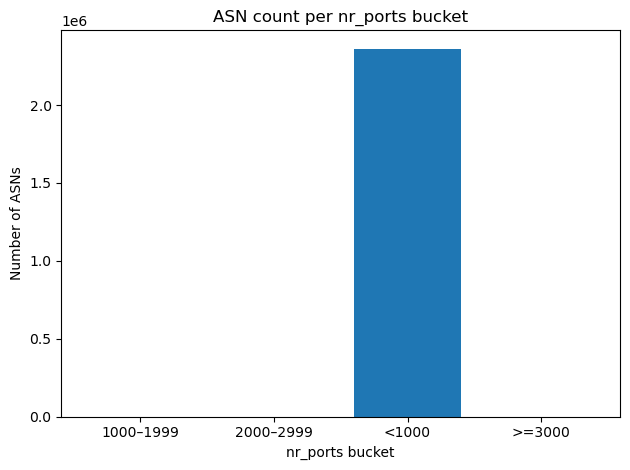

In [25]:
pdf = bucket_censys_anycast_pdf.copy()

plt.figure()
plt.bar(pdf["bucket"], pdf["count"])
plt.xlabel("nr_ports bucket")
plt.ylabel("Number of ASNs")
plt.title("ASN count per nr_ports bucket")
plt.tight_layout()
plt.show()

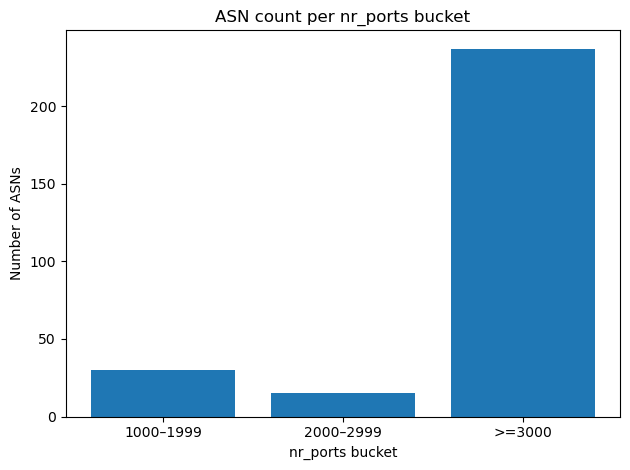

In [22]:
pdf = bucket_censys_anycast_pdf[bucket_censys_anycast_pdf["bucket"] != "<1000"].copy()

plt.figure()
plt.bar(pdf["bucket"], pdf["count"])
plt.xlabel("nr_ports bucket")
plt.ylabel("Number of ASNs")
plt.title("ASN count per nr_ports bucket")
plt.tight_layout()
plt.show()

In [23]:
censys_anycast_df.withColumn(
    "nr_ports", psf.size(psf.col("port"))
).filter(
    psf.col("nr_ports") < 1000
).select(psf.explode_outer("port").alias("port")).groupBy("port").count().sort("count", ascending=False).show()

+----+-------+
|port|  count|
+----+-------+
| 443|1797548|
|  80|1577283|
|8080| 747848|
|8443| 744735|
|2096| 736930|
|8880| 732794|
|2083| 732748|
|2087| 732628|
|2082| 732596|
|2086| 732593|
|2095| 732569|
|2053| 732243|
|2052| 727589|
|9801| 385583|
|1445| 385482|
|6599| 385367|
|  53| 111279|
|  25|  56449|
| 110|  48347|
| 993|  47721|
+----+-------+
only showing top 20 rows



In [24]:
censys_anycast_df.withColumn(
    "nr_ports", psf.size(psf.col("port"))
).filter(
    psf.col("nr_ports") < 1000
).select(psf.explode_outer("port").alias("port")).groupBy("port").count().count()

50911

In [29]:
censys_small_open_port_bucket = censys_anycast_df.withColumn(
    "nr_ports", psf.size(psf.col("port"))
).filter(
    psf.col("nr_ports") < 1000
).select(psf.explode_outer("port").alias("port")).distinct().toPandas()["port"].tolist()

In [27]:
# tab delimited file
nmap_services_pdf = pd.read_csv("nmap-services", delimiter="\t")
nmap_services_pdf.columns = ["service_name", "portnum_protocol", "open_frequency", "optional_comments"]
nmap_services_pdf.sort_values(by=["open_frequency"], ascending=False, inplace=True)

default_nmap_ports_pdf = nmap_services_pdf.head(1000).copy()
default_nmap_ports_pdf["port"] = default_nmap_ports_pdf["portnum_protocol"].apply(lambda x: x.split("/")[0])

default_nmap_ports = default_nmap_ports_pdf["port"].tolist()

In [33]:
# top ports on nmap that are not found in censys
p = set()
for port in default_nmap_ports:
    if not int(port) in censys_small_open_port_bucket:
        p.add(int(port))

print(len(p), p)

136 {32775, 49160, 9, 47624, 26123, 32780, 49167, 17, 17939, 49172, 50708, 54807, 49178, 25627, 36893, 548, 49189, 34855, 49192, 49193, 61481, 34862, 49202, 32818, 49209, 4666, 49211, 29243, 27707, 48189, 49215, 4672, 42557, 57410, 49214, 30785, 25157, 33354, 3659, 33866, 49226, 64590, 3664, 33872, 26196, 43094, 38498, 57958, 31335, 30824, 26219, 35438, 626, 120, 31352, 48255, 27263, 42627, 27271, 23176, 36489, 30869, 2717, 158, 19616, 682, 31404, 686, 687, 40622, 26286, 6346, 207, 49360, 58075, 44253, 19682, 5351, 5355, 49393, 46836, 55544, 31481, 45818, 27899, 34555, 19197, 764, 51456, 7937, 40708, 51972, 53006, 34577, 34580, 37144, 25375, 39714, 26407, 39723, 6971, 53571, 26949, 59207, 42313, 34125, 62287, 2383, 41308, 31584, 54114, 48489, 43370, 47981, 44923, 45441, 22914, 903, 40847, 3986, 27027, 29078, 41370, 26026, 27064, 959, 25541, 59846, 27079, 22986, 57813, 51690, 62958, 50164, 6646, 30718}


In [35]:
censys_open_port_bucket = censys_anycast_df.withColumn(
    "nr_ports", psf.size(psf.col("port"))
).select(psf.explode_outer("port").alias("port")).distinct().toPandas()["port"].tolist()

In [36]:
p = set()
for port in default_nmap_ports:
    if not int(port) in censys_open_port_bucket:
        p.add(int(port))

print(len(p), p)

0 set()


how many HTTP I see on port 80?

In [12]:
service_name = "HTTP"

censys_anycast_df.filter(
    psf.array_contains(psf.col("service_name"), service_name)
).select("host_identifier.ipv4", psf.explode_outer(psf.arrays_zip("port", "service_name")),
).select("ipv4", "col.port", "col.service_name",
).filter(
    (psf.col("service_name") == service_name)
    & (psf.col("port") == 80)
).dropDuplicates(subset=["ipv4"]).count()

1576194

Game support (e.g. MINECRAFT)

In [20]:
service_name = "HTTP"

censys_anycast_df.filter(
    psf.array_contains(psf.col("service_name"), service_name)
).select("host_identifier", psf.explode_outer(psf.arrays_zip("port", "transport", "service_name", "banner", "headers"))
).select("host_identifier.ipv4", "col.port", "col.transport", "col.service_name", "col.banner", "col.headers"
).filter(
    psf.col("service_name").isin([service_name, "UNKNOWN"])
).filter(
    (psf.col("banner").isNotNull())
    & (psf.length(psf.col("banner")) > 0)
    & (psf.col("port") == 443)
    & (psf.col("service_name") == "UNKNOWN")
).withColumn(
    "banner_str",
    psf.decode("banner", "ASCII")
).select("ipv4", "port", "transport", "service_name", "headers", "banner_str").show(5, truncate=False)

+-------------+----+---------+------------+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ipv4         |port|transport|service_name|headers|banner_str                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
+-